Week 2 - Data Exploration



*   Load a minimum of 6 months of dataset into pandas.
*   Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.
*   Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).
*   **Deliverable**: Jupyter notebook 01_exploration.ipynb with basic EDA plots.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

files = glob.glob("/content/drive/MyDrive/csv/CRMLSSold*.csv")
print(f"Found {len(files)} files")

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df = df.loc[:, ~df.columns.duplicated()]  # just in case a file repeats a column name

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 28 files
Loaded 615,707 rows, 84 columns


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,OriginatingSystemName,OriginatingSystemSubName
0,PismoCoast,PismoCoast,NaN,NaN,NaN,NaN,NaN,1.5,542243082,bill@richardsonproperties.com,...,93401,NaN,84942.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,NaN,1000000.0,537129950,melvinahomes@gmail.com,...,91935,0.0,3219955.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RanchoSoutheast,RanchoSoutheast,NaN,NaN,NaN,NaN,NaN,990000.0,536732813,realtylydia@gmail.com,...,90002,NaN,4688.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RimOTheWorld,RimOTheWorld,NaN,True,NaN,NaN,NaN,13500.0,526278483,nikki.howard1958@gmail.com,...,92352,0.0,5696.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,275000.0,523240472,WENDELLTU@AOL.COM,...,92223,0.0,264409.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df[
    (df["PropertyType"] == "Residential")
    & (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
print(f"Rows after filter: {len(df):,}")
print("Date range:", df["CloseDate"].min(), "to", df["CloseDate"].max())
print("Months covered:", df["CloseDate"].dt.to_period("M").nunique())

Rows after filter: 309,735
Date range: 2024-01-01 00:00:00 to 2026-04-30 00:00:00
Months covered: 28


,ClosePrice
count,309733.0
mean,1297553.0
std,5643293.0
min,0.0
25%,625000.0
50%,894000.0
75%,1430000.0
max,989500000.0


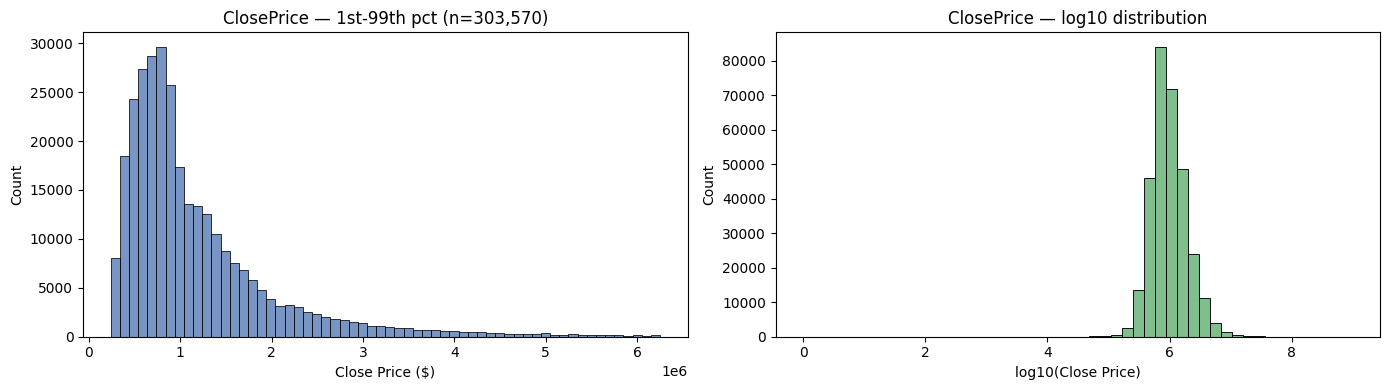

In [ ]:
display(df["ClosePrice"].describe().round(0).to_frame())

lo, hi = df["ClosePrice"].quantile([0.01, 0.99])
trimmed = df["ClosePrice"][(df["ClosePrice"] >= lo) & (df["ClosePrice"] <= hi)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(trimmed, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"ClosePrice — 1st-99th pct (n={len(trimmed):,})")
axes[0].set_xlabel("Close Price ($)")

sns.histplot(np.log10(df["ClosePrice"].dropna().clip(lower=1)), bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("ClosePrice — log10 distribution")
axes[1].set_xlabel("log10(Close Price)")
plt.tight_layout(); plt.show()

**Observations - ClosePrice**

The distribution is heavily right-skewed, as expected for home prices. Most sales cluster between roughly 300k and 1.5M, with a long tail reaching into the tens of millions. The log10 view makes this skew look close to log-normal, which is typical for price data.

There's a notable anomaly: the 25th percentile is just 55,000 and the log10 plot shows a distinct second cluster of prices under 100, clearly separate from the main distribution. This isn't a handful of outliers, it points to a substantial chunk of rows with corrupted or placeholder ClosePrice values that will need to be addressed before any modeling work.

,LivingArea
count,309569.0
mean,2034.0
std,1058.0
min,0.0
25%,1376.0
50%,1804.0
75%,2421.0
max,123764.0


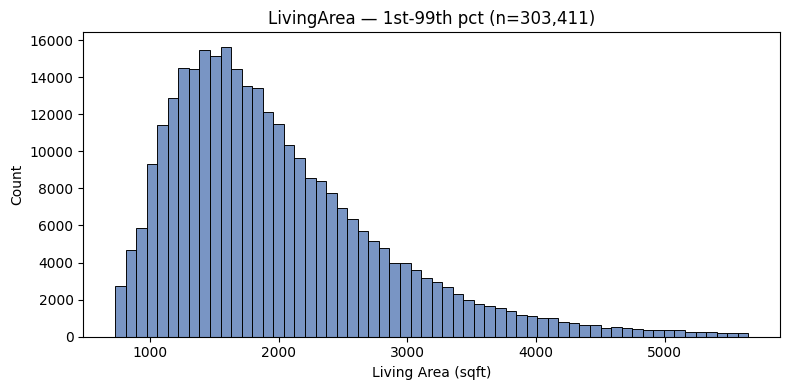

In [ ]:
display(df["LivingArea"].describe().round(0).to_frame())

lo, hi = df["LivingArea"].quantile([0.01, 0.99])
trimmed = df["LivingArea"][(df["LivingArea"] >= lo) & (df["LivingArea"] <= hi)]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(trimmed, bins=60, ax=ax, color="#4C72B0")
ax.set_title(f"LivingArea — 1st-99th pct (n={len(trimmed):,})")
ax.set_xlabel("Living Area (sqft)")
plt.tight_layout(); plt.show()

**Observations - LivingArea**

This distribution is the cleanest of the five - unimodel right-skewed, peaking around 1,300-1,500 sqft and tapering off smoothly towards 5,000+ sqft with no major outlier spikes visible even before trimming. The shape is consistent with what's expected for single-family homes, and the data appears largely trustworthy here.

,BedroomsTotal
count,309735.00
mean,3.48
std,0.96
min,0.00
25%,3.00
50%,3.00
75%,4.00
max,45.00


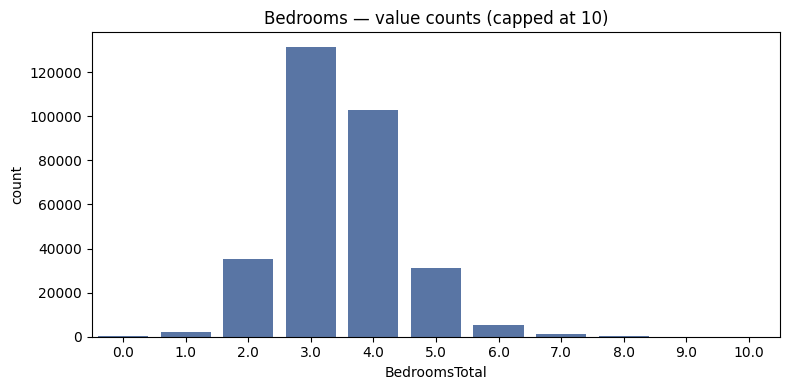

In [ ]:
display(df["BedroomsTotal"].describe().round(2).to_frame())

capped = df["BedroomsTotal"].dropna().clip(upper=10)
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x=capped, order=sorted(capped.unique()), color="#4C72B0", ax=ax)
ax.set_title("Bedrooms — value counts (capped at 10)")
plt.tight_layout(); plt.show()

**Observations - Bedrooms**

Strongly concentrated at 2-4 bedrooms, with 3 bedrooms as the clear mode (about 215k of 575k homes). Counts drop off sharply above 5 bedrooms. The describe() output shows a max of 180 bedrooms, which is obviously a data-entry error - but it's rare enough that it doesn't distort the visible shape of the distribution once capped at 10 for plotting.

,BathroomsTotalInteger
count,309685.00
mean,2.62
std,1.20
min,0.00
25%,2.00
50%,2.00
75%,3.00
max,175.00


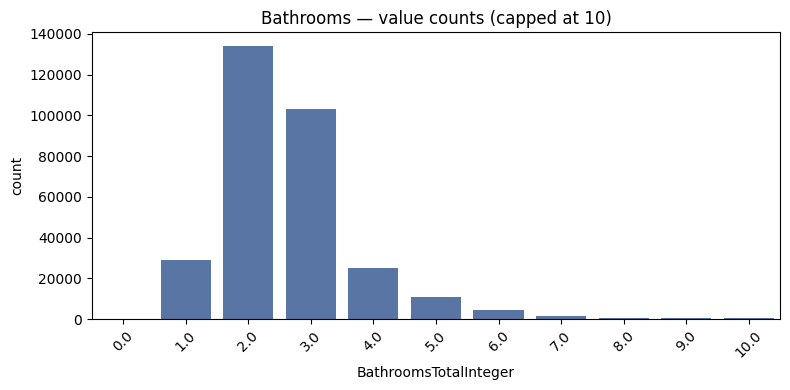

In [ ]:
display(df["BathroomsTotalInteger"].describe().round(2).to_frame())

capped = df["BathroomsTotalInteger"].dropna().clip(upper=10)
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x=capped, order=sorted(capped.unique()), color="#4C72B0", ax=ax)
ax.set_title("Bathrooms — value counts (capped at 10)")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Observations - Bathrooms**

Similarly concentrated, peaking at 2 bathrooms (about 245k homes) with 1 and 3 close behind. The distribution is narrower than Bedrooms, which makes sense - homes rarely have more bathrooms than bedrooms. Like Bedrooms, there's an extreme max value (175) that's clearly erroneous but doesn't meaningfully affect the plotted shape.

,LotSizeSquareFeet
count,3.044080e+05
mean,2.666650e+05
std,1.460283e+07
min,0.000000e+00
25%,5.663000e+03
50%,7.245000e+03
75%,1.035000e+04
max,2.087221e+09


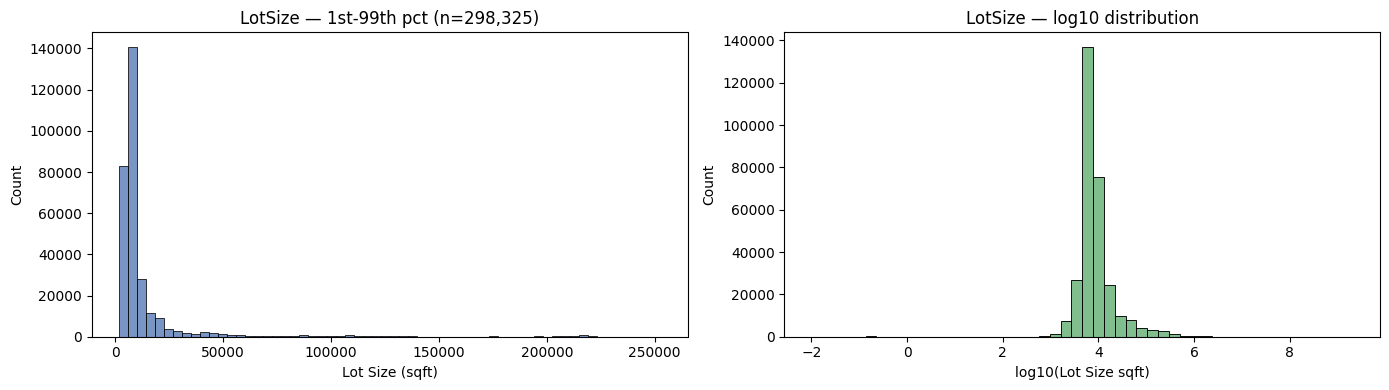

In [ ]:
display(df["LotSizeSquareFeet"].describe().round(0).to_frame())

lo, hi = df["LotSizeSquareFeet"].quantile([0.01, 0.99])
trimmed = df["LotSizeSquareFeet"][(df["LotSizeSquareFeet"] >= lo) & (df["LotSizeSquareFeet"] <= hi)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(trimmed, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"LotSize — 1st-99th pct (n={len(trimmed):,})")
axes[0].set_xlabel("Lot Size (sqft)")

positive = df["LotSizeSquareFeet"].dropna()
positive = positive[positive > 0]
sns.histplot(np.log10(positive), bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("LotSize — log10 distribution")
axes[1].set_xlabel("log10(Lot Size sqft)")
plt.tight_layout(); plt.show()

**Observations - LotSize**

This the most problematic of the five fields. Even after trimming to the 1st-99th percentile, the histogram is still dominated by a single tall spike near zero, because the underlying skew is so extreme (max value of ~5.2 billion sqft - larger than the land area of California). The log10 view is more informative: it shows the real distribution centered around 3,000-30,000 sqft, but also reveals a small stray cluster of lots under 1 sqft, indicating the same kind of placeholder/corrupted-value problem seen in ClosePrice.

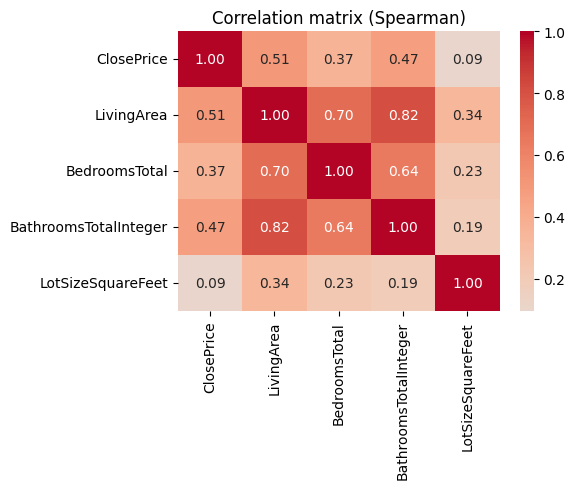

In [ ]:
cols = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
corr = df[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (Spearman)")
plt.tight_layout(); plt.show()

**Observations - Correlation Matrix**

LivingArea has the strongest relationship with ClosePrice (p = 0.47), which is expected - square footage is typically the single best predictor of home price. Bedrooms (0.43) and Bathrooms (0.35) are moderately correlated with price, largely because they're themselves correlated with LivingArea (p = 0.78 and 0.78 respectfully) - bigger homes tend to have more rooms. LotSize stands out as having almost no relationship with ClosePrice (p = 0.04), which is unusual for real estate data and is likely suppressed by the data-quality issues noted above rather than reflecting a true lack of relationship.